**Install TensorFlow**

In [ ]:
!pip install tensorflow

**Import the required libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

**Upload the feature dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving master_features.csv to master_features.csv


**Check uploaded files**

In [ ]:
import os
print(os.listdir())

['.config', 'master_features.csv', 'drive', 'sample_data']


**Load the feature dataset**

In [ ]:
import pandas as pd

features = pd.read_csv("master_features.csv")

print(features.shape)
features.head()

(8622, 2055)


,Label,MolecularWeight,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,FP_0,FP_1,FP_2,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,1,286.239,1.59282,4,6,115.06,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,154.253,2.50370,1,1,20.23,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,230.310,5.02060,0,0,0.00,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,108.140,1.70062,1,1,20.23,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,313.747,3.18870,0,6,58.40,7,0,1,0,...,0,0,0,0,0,0,0,0,0,0


**Separate predictors and target labels**

In [ ]:
X = features.drop("Label", axis=1)
y = features["Label"]

print(X.shape)
print(y.shape)

(8622, 2054)
(8622,)


**Split the dataset**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_test, X_external, y_test, y_external = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(X_external.shape)

(5173, 2054)
(1724, 2054)
(1725, 2054)


**Standardize the input features**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_external = scaler.transform(X_external)

**Build the Deep Neural Network**

In [ ]:
model = tf.keras.Sequential([

    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')

])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,052,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224,705 (4.67 MB)

 Trainable params: 1,224,705 (4.67 MB)

 Non-trainable params: 0 (0.00 B)

**Define Early Stopping**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

**Train the Deep Neural Network**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6934 - loss: 0.5844 - val_accuracy: 0.8039 - val_loss: 0.4511
Epoch 2/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8512 - loss: 0.3480 - val_accuracy: 0.8103 - val_loss: 0.4296
Epoch 3/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9117 - loss: 0.2225 - val_accuracy: 0.8010 - val_loss: 0.5278
Epoch 4/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9412 - loss: 0.1618 - val_accuracy: 0.7976 - val_loss: 0.5981
Epoch 5/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9573 - loss: 0.1139 - val_accuracy: 0.8016 - val_loss: 0.7984
Epoch 6/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9621 - loss: 0.1045 - val_accuracy: 0.8034 - val_loss: 0.7885
Epoch 7/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9739 - loss: 0.0665 - val_accuracy: 0.8092 - val_loss: 1.0134
Epoch 8/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9764 - loss: 0.0652 - 

**Predict toxicity labels**

In [ ]:
y_prob_test = model.predict(X_test)
y_pred_test = (y_prob_test > 0.5).astype(int)

y_prob_external = model.predict(X_external)
y_pred_external = (y_prob_external > 0.5).astype(int)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


**Evaluate the test dataset**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("===== Test Set =====")

print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall   :", recall_score(y_test, y_pred_test))
print("F1-score :", f1_score(y_test, y_pred_test))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_test))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred_test))

===== Test Set =====
Accuracy : 0.8103248259860789
Precision: 0.8156626506024096
Recall   : 0.7955346650998825
F1-score : 0.8054729327781083
ROC-AUC  : 0.8873449873001643

Confusion Matrix
[[720 153]
 [174 677]]


**Evaluate the external validation dataset**

In [ ]:
print("===== External Validation =====")

print("Accuracy :", accuracy_score(y_external, y_pred_external))
print("Precision:", precision_score(y_external, y_pred_external))
print("Recall   :", recall_score(y_external, y_pred_external))
print("F1-score :", f1_score(y_external, y_pred_external))
print("ROC-AUC  :", roc_auc_score(y_external, y_prob_external))

print("\nConfusion Matrix")

print(confusion_matrix(y_external, y_pred_external))

===== External Validation =====
Accuracy : 0.8092753623188406
Precision: 0.8030127462340672
Recall   : 0.8133802816901409
F1-score : 0.8081632653061225
ROC-AUC  : 0.8799348208379717

Confusion Matrix
[[703 170]
 [159 693]]


**Create an output folder**

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook6_Output", exist_ok=True)

print("Folder created successfully!")

Folder created successfully!


**Plot and save the ROC curve (Test Set)**

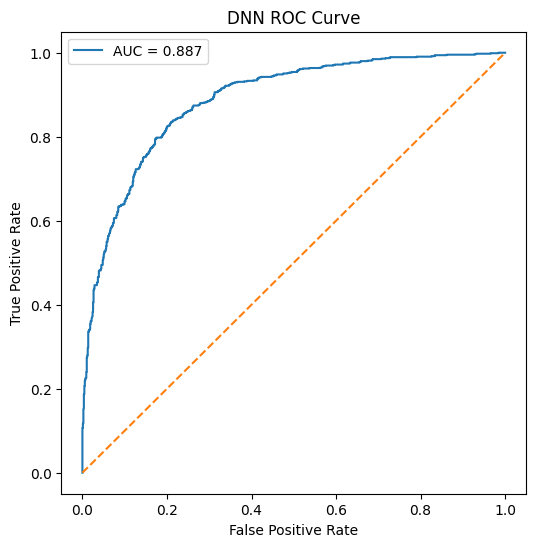

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DNN ROC Curve")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Notebook6_Output/DNN_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot and save the ROC curve (External Validation)**

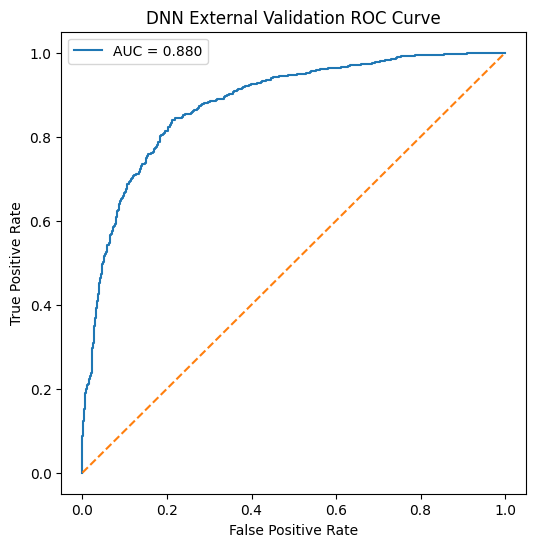

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_external, y_prob_external)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DNN External Validation ROC Curve")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Notebook6_Output/DNN_External_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot and save the test confusion matrix**

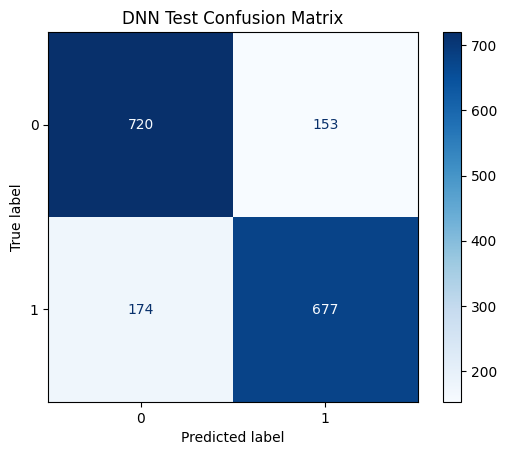

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap="Blues"
)

plt.title("DNN Test Confusion Matrix")

plt.savefig(
    "/content/drive/MyDrive/Notebook6_Output/DNN_Test_ConfusionMatrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot the external validation Confusion Matrix**

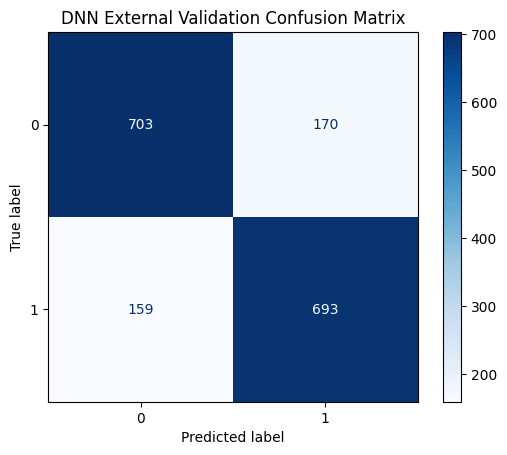

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_external,
    y_pred_external,
    cmap="Blues"
)

plt.title("DNN External Validation Confusion Matrix")

plt.savefig(
    "/content/drive/MyDrive/Notebook6_Output/DNN_External_ConfusionMatrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**PLot the training and validation accuracy**

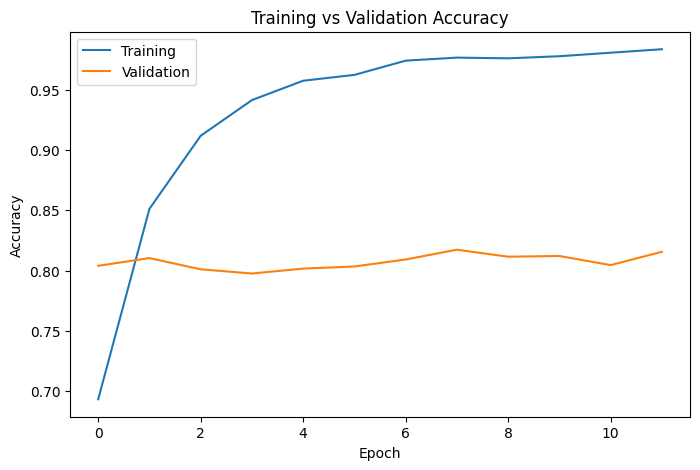

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Notebook6_Output/DNN_Accuracy_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot the training and validation loss**

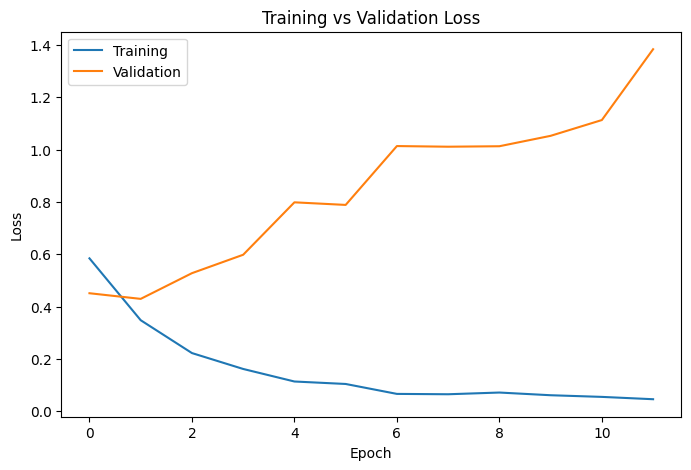

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Notebook6_Output/DNN_Loss_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook6_Output", exist_ok=True)

**Save the trained DNN model**

In [ ]:
model.save("/content/drive/MyDrive/Notebook6_Output/DNN_Model.keras")

print("DNN model saved successfully!")

DNN model saved successfully!


**Generate the classification report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       873
           1       0.82      0.80      0.81       851

    accuracy                           0.81      1724
   macro avg       0.81      0.81      0.81      1724
weighted avg       0.81      0.81      0.81      1724



**Calculate the PR-AUC score**

In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob_test)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8850571378436258


**Plot the Precision–Recall curve**

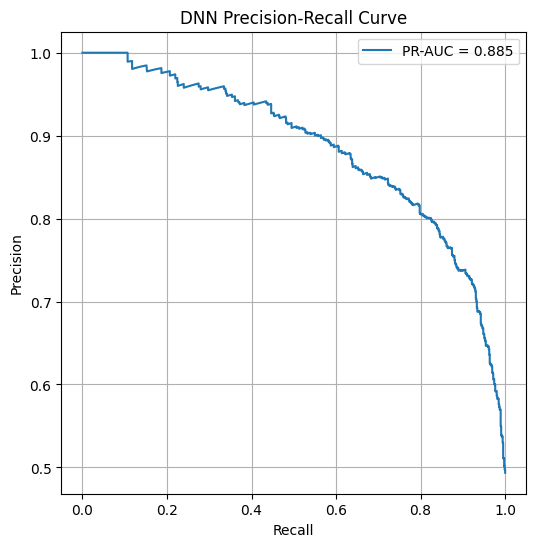

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_test)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("DNN Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/Notebook6_Output/DNN_PR_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Calculate the ROC-AUC score**

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob_test)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8873449873001643


**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Create the output folder**

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook6_Output", exist_ok=True)

**Display the trained model**

In [ ]:
print(model)

<Sequential name=sequential, built=True>


**Save the model again**

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook6_Output", exist_ok=True)

model.save("/content/drive/MyDrive/Notebook6_Output/DNN_model.keras")

print("DNN model saved successfully!")

DNN model saved successfully!


**Verify the saved model**

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Notebook6_Output/DNN_model.keras"))

True
